Indexed model files: 72


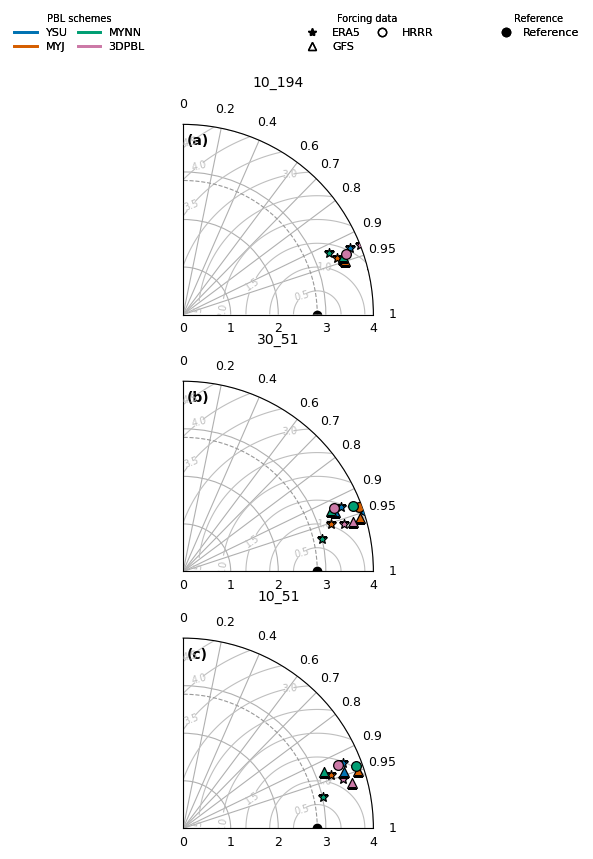

Saved: taylor_ws/taylor_ws_E05_200m.[pdf/png]


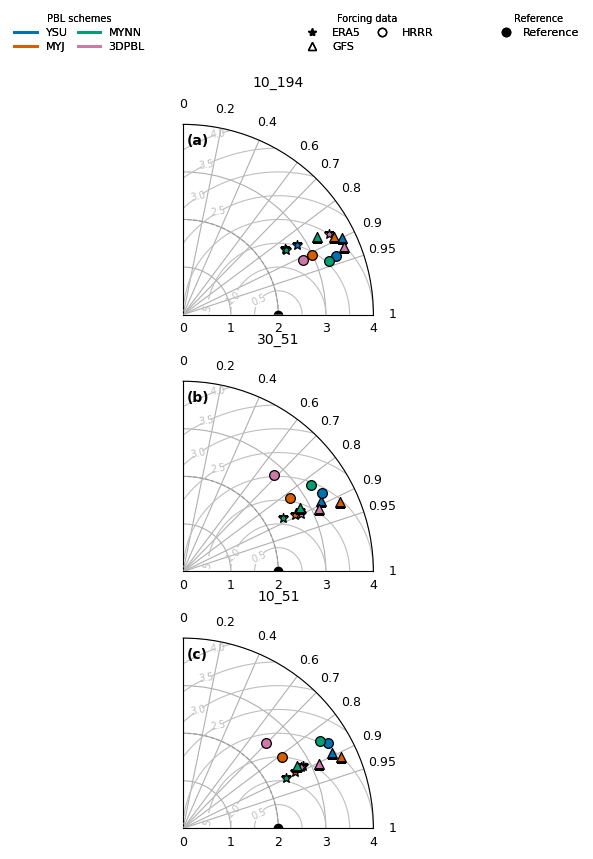

Saved: taylor_ws/taylor_ws_E06_200m.[pdf/png]
Done. Outputs in: taylor_ws


In [29]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
WS_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
WS_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"
OUT_ROOT         = "taylor_ws"

LOCATIONS = ["E05", "E06"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]
ICBCS     = ["era5", "gfs", "hrrr"]

HEIGHTS = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
HEIGHT_M = 200
RMAX_GLOBAL = 4.0
# ===================== Copernicus / WES styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE = (6.85, 8.8)
DPI_PNG = 300

# ===================== Encodings =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# ICBC markers following your previous plots
icbc_marker = {
    "era5": "*",
    "gfs": "^",
    "hrrr": "o",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# matches folder names like:
# era5_ysu_vert54
# gfs_myj_vert80
# hrrr_3dpbl_vert93
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

# ===================== Helpers =====================
def ensure_outdir():
    os.makedirs(OUT_ROOT, exist_ok=True)
    return OUT_ROOT

def parse_parts_from_parent(path):
    run_dir = os.path.basename(os.path.dirname(path))
    m = run_dir_pat.match(run_dir)
    if not m:
        return None
    g = m.groupdict()
    return g["icbc"], g["pbl"], g["vert"]

def collect_model_index():
    """
    Collect all model files from BOTH roots into one index.
    """
    out = []
    seen = set()

    for root in [WS_D02_ROOT, WS_ALLRUNS_ROOT]:
        for loc in LOCATIONS:
            patt = os.path.join(root, "**", f"WS_{loc}.npy")
            for f in glob.glob(patt, recursive=True):
                f = os.path.abspath(f)
                if f in seen:
                    continue
                seen.add(f)

                parsed = parse_parts_from_parent(f)
                if parsed is None:
                    continue

                icbc, pbl, vert = parsed
                out.append((f, icbc, pbl, vert, loc))

    return out

def load_obs(loc):
    fp = os.path.join(os.getcwd(), f"WS_{loc}_OBS.npy")
    if not os.path.exists(fp):
        raise FileNotFoundError(f"OBS file not found: {fp}")
    arr = np.load(fp)
    if arr.ndim != 2 or arr.shape[1] != len(HEIGHTS):
        raise ValueError(f"Expected OBS shape (time,{len(HEIGHTS)}), got {arr.shape} in {fp}")
    return arr

def load_model(path):
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != len(HEIGHTS):
        raise ValueError(f"Expected model shape (time,{len(HEIGHTS)}), got {arr.shape} in {path}")
    return arr

def get_height_index(height_m):
    if height_m not in HEIGHTS:
        raise ValueError(f"HEIGHT_M={height_m} not in HEIGHTS={HEIGHTS.tolist()}")
    return int(np.where(HEIGHTS == height_m)[0][0])

def compute_taylor_stats(obs, mod):
    """
    Returns:
      std_obs, std_mod, corr, crmse
    """
    mask = np.isfinite(obs) & np.isfinite(mod)
    obs = obs[mask]
    mod = mod[mask]

    if len(obs) < 2:
        return np.nan, np.nan, np.nan, np.nan

    std_obs = np.std(obs, ddof=0)
    std_mod = np.std(mod, ddof=0)

    if std_obs == 0 or std_mod == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(obs, mod)[0, 1]

    crmse = np.sqrt(np.mean(((mod - np.mean(mod)) - (obs - np.mean(obs)))**2))
    return std_obs, std_mod, corr, crmse

def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

def add_top_legends(fig):
    """
    Top grouped legend blocks:
      - PBL schemes
      - Forcing data
      - Reference
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    forcing_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            color="black",
            marker=icbc_marker[i],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none" if i != "era5" else "black",
            markeredgewidth=1.0,
            label=i.upper()
        )
        for i in ["era5", "gfs", "hrrr"]
    ]

    ref_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            color="black",
            marker="o",
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="black",
            label="Reference"
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.26, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=forcing_handles,
        loc="upper center",
        bbox_to_anchor=(0.68, 1.01),
        frameon=False,
        ncol=2,
        title="Forcing data",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.93, 1.01),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.5,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)

def draw_taylor_panel(ax, records, panel_title, panel_txt, rmax, std_ref):
    """
    Taylor diagram in the standard quarter-circle layout:
      - standard deviation along the bottom horizontal baseline
      - correlation on the outer arc
      - centered RMSE as contours
    """
    # IMPORTANT:
    # Do NOT rotate the polar axis.
    # This keeps theta=0 on the bottom horizontal baseline,
    # so SD is read along the horizontal line, as in the usual Taylor diagram.
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_rlabel_position(0)  # SD labels along bottom baseline

    # Correlation ticks along outer arc
    corr_ticks = np.array([1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.4, 0.2, 0.0])
    theta_ticks = np.degrees(np.arccos(corr_ticks))
    theta_labels = [f"{c:.2g}" if c != 1 else "1" for c in corr_ticks]
    ax.set_thetagrids(theta_ticks, labels=theta_labels)

    # Radial limits
    ax.set_rlim(0, rmax)
    ax.tick_params(axis="y", pad=2)

    # Centered RMSE contours
    rs = np.linspace(0, rmax, 300)
    thetas = np.linspace(0, np.pi / 2, 300)
    TT, RR = np.meshgrid(thetas, rs)
    CRMSE = np.sqrt(std_ref**2 + RR**2 - 2 * RR * std_ref * np.cos(TT))

    max_contour = np.ceil(np.nanmax(CRMSE) * 2) / 2
    contour_levels = np.arange(0.5, max_contour + 0.001, 0.5)
    cs = ax.contour(TT, RR, CRMSE, levels=contour_levels, colors="0.75", linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

    # Reference point: black circle on the bottom horizontal baseline
    ax.plot(
        0, std_ref,
        marker="o",
        markersize=6,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        zorder=6
    )

    # Reference standard deviation arc
    theta_arc = np.linspace(0, np.pi / 2, 300)
    ax.plot(
        theta_arc,
        np.full_like(theta_arc, std_ref),
        color="0.6",
        linewidth=0.8,
        linestyle="--"
    )

    # Model points
    for rec in records:
        if not np.isfinite(rec["corr"]) or not np.isfinite(rec["std_mod"]):
            continue

        theta = np.arccos(np.clip(rec["corr"], -1, 1))
        r = rec["std_mod"]

        ax.plot(
            theta, r,
            linestyle="None",
            marker=icbc_marker[rec["icbc"]],
            markersize=7,
            markeredgecolor="black",
            markerfacecolor=pbl_color[rec["pbl"]],
            markeredgewidth=0.9,
            zorder=7
        )

    ax.set_title(panel_title, pad=8)
    panel_label(ax, panel_txt)

def make_taylor_figure(loc, idx):
    outdir = ensure_outdir()
    hidx = get_height_index(HEIGHT_M)

    obs_all = load_obs(loc)
    obs_ts = obs_all[:, hidx]

    recs_all = []
    for f, icbc, pbl, vert, L in idx:
        if L != loc:
            continue

        mod_all = load_model(f)
        mod_ts = mod_all[:, hidx]

        # align if lengths differ
        n = min(len(obs_ts), len(mod_ts))
        obs_use = obs_ts[:n]
        mod_use = mod_ts[:n]

        std_obs, std_mod, corr, crmse = compute_taylor_stats(obs_use, mod_use)
        if not np.isfinite(std_obs) or not np.isfinite(std_mod):
            continue

        recs_all.append({
            "file": f,
            "icbc": icbc,
            "pbl": pbl,
            "vert": vert,
            "std_obs": std_obs,
            "std_mod": std_mod,
            "corr": corr,
            "crmse": crmse,
        })

    if not recs_all:
        print(f"[{loc}] No valid records found.")
        return

    std_ref = recs_all[0]["std_obs"]

    # Same radial max for all 3 panels of the same buoy
    rmax = RMAX_GLOBAL

    # Split by vertical resolution
    rec54 = sorted(
        [r for r in recs_all if r["vert"] == "54"],
        key=lambda d: (ICBC_ORDER[d["icbc"]], PBL_ORDER[d["pbl"]])
    )
    rec80 = sorted(
        [r for r in recs_all if r["vert"] == "80"],
        key=lambda d: (ICBC_ORDER[d["icbc"]], PBL_ORDER[d["pbl"]])
    )
    rec93 = sorted(
        [r for r in recs_all if r["vert"] == "93"],
        key=lambda d: (ICBC_ORDER[d["icbc"]], PBL_ORDER[d["pbl"]])
    )

    fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, subplot_kw={"projection": "polar"})
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.88,
        bottom=0.08,
        wspace=0.1,
        hspace=0.35
    )

    draw_taylor_panel(axs[0], rec54, "10_194", "(a)", rmax, std_ref)
    draw_taylor_panel(axs[1], rec80, "30_51", "(b)", rmax, std_ref)
    draw_taylor_panel(axs[2], rec93, "10_51", "(c)", rmax, std_ref)

    add_top_legends(fig)

    # # Global annotations
    # axs[0].text(
    #     np.deg2rad(45), rmax * 1.07,
    #     "Correlation",
    #     fontsize=8, ha="center", va="center"
    # )

    # # Optional label near baseline
    # axs[2].text(
    #     np.deg2rad(2), rmax * 1.08,
    #     "Standard deviation (m s$^{-1}$)",
    #     fontsize=8, ha="center", va="bottom"
    # )

    base = f"taylor_ws_{loc}_{HEIGHT_M}m"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    idx = collect_model_index()
    print("Indexed model files:", len(idx))
    os.makedirs(OUT_ROOT, exist_ok=True)

    for loc in LOCATIONS:
        make_taylor_figure(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}")

Indexed model files: 72


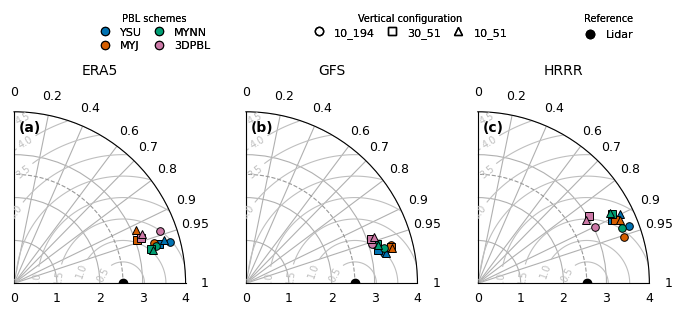

Saved: taylor_ws_3panel/taylor_ws_3panel_E05_140m.pdf
Saved: taylor_ws_3panel/taylor_ws_3panel_E05_140m.png


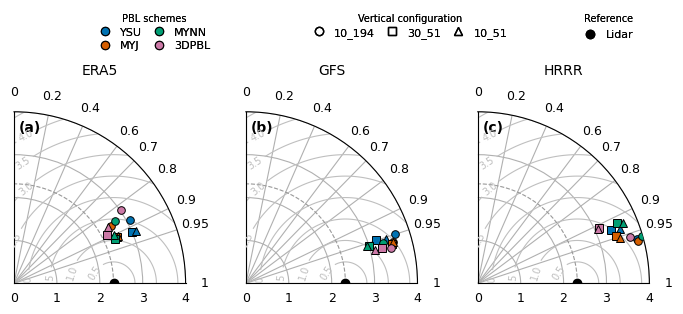

Saved: taylor_ws_3panel/taylor_ws_3panel_E06_140m.pdf
Saved: taylor_ws_3panel/taylor_ws_3panel_E06_140m.png
Done. Outputs in: taylor_ws_3panel


In [8]:
############################### 3 panel Taylor with icbc panels
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS =====================
WS_D02_ROOT      = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
WS_ALLRUNS_ROOT  = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"

OUT_ROOT = "taylor_ws_3panel"

LOCATIONS = ["E05", "E06"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]
ICBCS     = ["era5", "gfs", "hrrr"]

HEIGHTS = np.array(
    [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
)

HEIGHT_M = 140

# Keep identical radial limit for all Taylor panels
RMAX_GLOBAL = 4

# ===================== Copernicus / WES styling =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Full-width 1x3
FIGSIZE = (7.1, 3.3)
DPI_PNG = 300

# ===================== Encodings =====================

# PBL = color
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# Vertical configuration = marker
vert_marker = {
    "54": "o",
    "80": "s",
    "93": "^",
}

vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

ICBC_ORDER = {
    "era5": 0,
    "gfs": 1,
    "hrrr": 2,
}

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}

# Folder names:
# era5_ysu_vert54
# gfs_myj_vert80
# hrrr_3dpbl_vert93
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


# ===================== Helpers =====================
def ensure_outdir():

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    return OUT_ROOT


def parse_parts_from_parent(path):

    run_dir = os.path.basename(
        os.path.dirname(path)
    )

    m = run_dir_pat.match(run_dir)

    if not m:
        return None

    g = m.groupdict()

    return (
        g["icbc"],
        g["pbl"],
        g["vert"],
    )


def collect_model_index():
    """
    Collect model files from both roots.
    """

    out = []
    seen = set()

    for root in [
        WS_D02_ROOT,
        WS_ALLRUNS_ROOT,
    ]:

        for loc in LOCATIONS:

            patt = os.path.join(
                root,
                "**",
                f"WS_{loc}.npy"
            )

            for f in glob.glob(
                patt,
                recursive=True
            ):

                f = os.path.abspath(f)

                if f in seen:
                    continue

                seen.add(f)

                parsed = parse_parts_from_parent(f)

                if parsed is None:
                    continue

                icbc, pbl, vert = parsed

                out.append(
                    (
                        f,
                        icbc,
                        pbl,
                        vert,
                        loc,
                    )
                )

    return out


def load_obs(loc):

    fp = os.path.join(
        os.getcwd(),
        f"WS_{loc}_OBS.npy"
    )

    if not os.path.exists(fp):

        raise FileNotFoundError(
            f"OBS file not found: {fp}"
        )

    arr = np.load(fp)

    if (
        arr.ndim != 2
        or arr.shape[1] != len(HEIGHTS)
    ):

        raise ValueError(
            f"Expected OBS shape "
            f"(time,{len(HEIGHTS)}), "
            f"got {arr.shape} in {fp}"
        )

    return arr


def load_model(path):

    arr = np.load(path)

    if (
        arr.ndim != 2
        or arr.shape[1] != len(HEIGHTS)
    ):

        raise ValueError(
            f"Expected model shape "
            f"(time,{len(HEIGHTS)}), "
            f"got {arr.shape} in {path}"
        )

    return arr


def get_height_index(height_m):

    if height_m not in HEIGHTS:

        raise ValueError(
            f"HEIGHT_M={height_m} "
            f"not in HEIGHTS={HEIGHTS.tolist()}"
        )

    return int(
        np.where(
            HEIGHTS == height_m
        )[0][0]
    )


def compute_taylor_stats(obs, mod):
    """
    Returns:
      std_obs
      std_mod
      corr
      crmse
    """

    mask = (
        np.isfinite(obs)
        & np.isfinite(mod)
    )

    obs = obs[mask]
    mod = mod[mask]

    if len(obs) < 2:

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    std_obs = np.std(
        obs,
        ddof=0
    )

    std_mod = np.std(
        mod,
        ddof=0
    )

    if (
        std_obs == 0
        or std_mod == 0
    ):

        corr = np.nan

    else:

        corr = np.corrcoef(
            obs,
            mod
        )[0, 1]

    crmse = np.sqrt(
        np.mean(
            (
                (mod - np.mean(mod))
                -
                (obs - np.mean(obs))
            ) ** 2
        )
    )

    return (
        std_obs,
        std_mod,
        corr,
        crmse,
    )


def panel_label(ax, txt):

    ax.text(
        0.03,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


# ===================== Legends =====================
def add_top_legends(fig):
    """
    Encoding:
      color  = PBL scheme
      marker = vertical configuration

    IC/BC is represented by panel.
    """

    title_fs = 7
    label_fs = 8

    # ---------------- PBL ----------------
    pbl_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            marker="o",
            markersize=6,
            markeredgecolor="black",
            markeredgewidth=0.8,
            markerfacecolor=pbl_color[p],
            label=p.upper(),
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl",
        ]
    ]

    # ---------------- Vertical configuration ----------------
    vert_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            marker=vert_marker[v],
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="none",
            markeredgewidth=1.0,
            label=vert_to_label[v],
        )
        for v in [
            "54",
            "80",
            "93",
        ]
    ]

    # ---------------- Reference ----------------
    ref_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            marker="o",
            markersize=6,
            markeredgecolor="black",
            markerfacecolor="black",
            label="Lidar",
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.27, 1.01),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.2,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg2 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.63, 1.01),
        frameon=False,
        ncol=3,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.2,
        columnspacing=0.9,
        labelspacing=0.30,
        borderaxespad=0.0,
    )

    leg3 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.91, 1.01),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.2,
        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ===================== Taylor panel =====================
def draw_taylor_panel(
    ax,
    records,
    panel_title,
    panel_txt,
    rmax,
    std_ref,
):
    """
    Standard quarter-circle Taylor diagram.

    Radius:
        standard deviation

    Outer arc:
        Pearson correlation coefficient

    Gray contours:
        centered RMSE
    """

    # Quarter circle
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    # SD values along horizontal baseline
    ax.set_rlabel_position(0)

    # ---------------- Correlation ticks ----------------
    corr_ticks = np.array([
        1.0,
        0.95,
        0.9,
        0.8,
        0.7,
        0.6,
        0.4,
        0.2,
        0.0,
    ])

    theta_ticks = np.degrees(
        np.arccos(corr_ticks)
    )

    theta_labels = [
        f"{c:.2g}" if c != 1
        else "1"
        for c in corr_ticks
    ]

    ax.set_thetagrids(
        theta_ticks,
        labels=theta_labels,
    )

    # ---------------- Radial range ----------------
    ax.set_rlim(
        0,
        rmax
    )

    ax.tick_params(
        axis="y",
        pad=2
    )

    # ---------------- cRMSE contours ----------------
    rs = np.linspace(
        0,
        rmax,
        300
    )

    thetas = np.linspace(
        0,
        np.pi / 2,
        300
    )

    TT, RR = np.meshgrid(
        thetas,
        rs
    )

    CRMSE = np.sqrt(
        std_ref**2
        + RR**2
        - 2
        * RR
        * std_ref
        * np.cos(TT)
    )

    max_contour = (
        np.ceil(
            np.nanmax(CRMSE) * 2
        ) / 2
    )

    contour_levels = np.arange(
        0.5,
        max_contour + 0.001,
        0.5
    )

    cs = ax.contour(
        TT,
        RR,
        CRMSE,
        levels=contour_levels,
        colors="0.75",
        linewidths=0.8,
    )

    ax.clabel(
        cs,
        inline=True,
        fontsize=7,
        fmt="%.1f",
    )

    # ---------------- Reference point ----------------
    ax.plot(
        0,
        std_ref,
        marker="o",
        markersize=6,
        linestyle="None",
        markerfacecolor="black",
        markeredgecolor="black",
        zorder=8,
    )

    # Reference SD arc
    theta_arc = np.linspace(
        0,
        np.pi / 2,
        300
    )

    ax.plot(
        theta_arc,
        np.full_like(
            theta_arc,
            std_ref
        ),
        color="0.6",
        linewidth=0.8,
        linestyle="--",
        zorder=2,
    )

    # ---------------- Model points ----------------
    for rec in records:

        if (
            not np.isfinite(rec["corr"])
            or not np.isfinite(rec["std_mod"])
        ):
            continue

        # Current figure uses non-negative-correlation
        # quarter-circle Taylor diagrams.
        if rec["corr"] < 0:
            print(
                f"Warning: negative correlation "
                f"{rec['corr']:.3f} for "
                f"{rec['icbc']} "
                f"{rec['pbl']} "
                f"vert{rec['vert']} "
                f"will fall outside the 0-1 "
                f"Taylor correlation range."
            )

        theta = np.arccos(
            np.clip(
                rec["corr"],
                -1,
                1
            )
        )

        r = rec["std_mod"]

        ax.plot(
            theta,
            r,
            linestyle="None",

            # Vertical configuration
            marker=vert_marker[
                rec["vert"]
            ],

            markersize=5.5,

            # PBL
            markerfacecolor=pbl_color[
                rec["pbl"]
            ],

            markeredgecolor="black",
            markeredgewidth=0.7,
            zorder=7,
        )

    ax.set_title(
        panel_title,
        pad=8
    )

    panel_label(
        ax,
        panel_txt
    )


# ===================== Make figure =====================
def make_taylor_figure(
    loc,
    idx
):

    outdir = ensure_outdir()

    hidx = get_height_index(
        HEIGHT_M
    )

    obs_all = load_obs(
        loc
    )

    obs_ts = obs_all[
        :,
        hidx
    ]

    recs_all = []

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if L != loc:
            continue

        mod_all = load_model(f)

        mod_ts = mod_all[
            :,
            hidx
        ]

        # Match lengths if needed
        n = min(
            len(obs_ts),
            len(mod_ts)
        )

        obs_use = obs_ts[:n]
        mod_use = mod_ts[:n]

        (
            std_obs,
            std_mod,
            corr,
            crmse,
        ) = compute_taylor_stats(
            obs_use,
            mod_use
        )

        if (
            not np.isfinite(std_obs)
            or not np.isfinite(std_mod)
        ):
            continue

        recs_all.append({
            "file": f,
            "icbc": icbc,
            "pbl": pbl,
            "vert": vert,
            "std_obs": std_obs,
            "std_mod": std_mod,
            "corr": corr,
            "crmse": crmse,
        })

    if not recs_all:

        print(
            f"[{loc}] No valid records found."
        )

        return

    std_ref = recs_all[0][
        "std_obs"
    ]

    rmax = RMAX_GLOBAL

    # ===================== Split by IC/BC =====================
    rec_era5 = sorted(
        [
            r for r in recs_all
            if r["icbc"] == "era5"
        ],
        key=lambda d: (
            PBL_ORDER[d["pbl"]],
            VERT_ORDER[d["vert"]],
        )
    )

    rec_gfs = sorted(
        [
            r for r in recs_all
            if r["icbc"] == "gfs"
        ],
        key=lambda d: (
            PBL_ORDER[d["pbl"]],
            VERT_ORDER[d["vert"]],
        )
    )

    rec_hrrr = sorted(
        [
            r for r in recs_all
            if r["icbc"] == "hrrr"
        ],
        key=lambda d: (
            PBL_ORDER[d["pbl"]],
            VERT_ORDER[d["vert"]],
        )
    )

    # ===================== 1x3 =====================
    fig, axs = plt.subplots(
        1,
        3,
        figsize=FIGSIZE,
        subplot_kw={
            "projection": "polar"
        }
    )

    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        top=0.70,
        bottom=0.18,
        wspace=0.18,
    )

    draw_taylor_panel(
        axs[0],
        rec_era5,
        "ERA5",
        "(a)",
        rmax,
        std_ref,
    )

    draw_taylor_panel(
        axs[1],
        rec_gfs,
        "GFS",
        "(b)",
        rmax,
        std_ref,
    )

    draw_taylor_panel(
        axs[2],
        rec_hrrr,
        "HRRR",
        "(c)",
        rmax,
        std_ref,
    )

    add_top_legends(
        fig
    )

    # ===================== Save =====================
    base = (
        f"taylor_ws_3panel_"
        f"{loc}_{HEIGHT_M}m"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ===================== RUN =====================
if __name__ == "__main__":

    idx = collect_model_index()

    print(
        "Indexed model files:",
        len(idx)
    )

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    for loc in LOCATIONS:

        make_taylor_figure(
            loc,
            idx
        )

    print(
        f"Done. Outputs in: {OUT_ROOT}"
    )